# Fast AI training

After attempting the project in the PyTorch and PyTorch Lightning frameworks, I finally decided to learn fast AI.

After running multiple controlled experiments, I used the following model structure as my "backup" submission. It was designed to be as generalizable as possible. It never scored the highest on the Public Leaderboard, but ended up being quite good once the other 75% of the data was released.

### **THIS NOTEBOOK IS AN EXAMPLE ONLY**

In reality this notebook was split up into two parts, a training part (which had 12 models and took all of 9 hours) and a submission notebook. You will see in my notes below where this split occurs.

In [1]:
#First we need to import our models
import sys
# sys.path.append('../input/timm-pytorch-image-models/pytorch-image-models-master')
from timm import create_model

/home/rxchi1d/anaconda3/envs/ML2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import pandas as pd
import math
import pickle
import gc

import fastai
from fastai.vision.all import *

import torch
from torch import nn
from torch.nn import functional as F

import torchvision
from torchvision import transforms as T
from torchvision.io import read_image

import sklearn
from sklearn.model_selection import StratifiedKFold

In [3]:
torch.__version__

'2.0.0'

In [4]:
# import timm
# timm.list_models()

In [5]:
class args:
  folder_name = Path('../input/petfinder-pawpularity-score')
  seed = 1212
  num_splits = 12 #Normally I have this set to 12, because that is the most I can train in 9 hours
  batch_size = 16
  num_workers = 8
  imagesize = 384
  model_name = 'swin_large_patch4_window12_384'

In [6]:
#First we read in our training data and create a new column with the image file locations
df = pd.read_csv(args.folder_name/"train.csv")
df['filename'] = df['Id'].map(lambda x:str(args.folder_name/'train'/x)+'.jpg')

#feature_cols = [col for col in df.columns if col not in ['Id', 'Pawpularity', 'filename']]

In [7]:
#Lets take a look and make sure the data is structured right
df.head()

,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity,filename
0,0007de18844b0dbbb5e1f607da0606e0,0,1,1,1,0,0,1,0,0,0,0,0,63,../input/petfinder-pawpularity-score/train/0007de18844b0dbbb5e1f607da0606e0.jpg
1,0009c66b9439883ba2750fb825e1d7db,0,1,1,0,0,0,0,0,0,0,0,0,42,../input/petfinder-pawpularity-score/train/0009c66b9439883ba2750fb825e1d7db.jpg
2,0013fd999caf9a3efe1352ca1b0d937e,0,1,1,1,0,0,0,0,1,1,0,0,28,../input/petfinder-pawpularity-score/train/0013fd999caf9a3efe1352ca1b0d937e.jpg
3,0018df346ac9c1d8413cfcc888ca8246,0,1,1,1,0,0,0,0,0,0,0,0,15,../input/petfinder-pawpularity-score/train/0018df346ac9c1d8413cfcc888ca8246.jpg
4,001dc955e10590d3ca4673f034feeef2,0,0,0,1,0,0,1,0,0,0,0,0,72,../input/petfinder-pawpularity-score/train/001dc955e10590d3ca4673f034feeef2.jpg


In [8]:
#Setting seeds for reproducibility
seed = args.seed

device = torch.device("cuda:0")

set_seed(seed, reproducible=True)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True

In [9]:
#BCE logits works best when we are working with numbers between 0 and 1, so we will rescale the Pawpularity
df = df.drop(columns=['Id'])
df = df.sample(frac=1).reset_index(drop=True)
df['norm_score'] = df['Pawpularity']/100

#Rice rule
num_bins = int(np.ceil(2*((len(df))**(1./3))))

df['bins'] = pd.cut(df['norm_score'], bins=num_bins, labels=False)

#Now we create our Folds. First we create a new column and assign it the value of -1
#This allows us to tell if we have had an issue (because our process should change this number)
df['fold'] = -1

#Now we assign a number representing the fold number(0-11) to the fold column based on a stratified random
#sample
strat_kfold = StratifiedKFold(n_splits=args.num_splits, random_state=seed, shuffle=True)
for i, (_, train_index) in enumerate(strat_kfold.split(df.index, df['bins'])):
    df.iloc[train_index, -1] = i

In [10]:
#This will be our training metric
def rmse(input,target):
    return 100*torch.sqrt(F.mse_loss(torch.sigmoid(input.flatten()), target))

In [11]:
def get_data(fold):
    
    #Here we create a copy of the data, and assign the fold whose number matches the current fold num to
    #the validation set
    df_f = df.copy()
    df_f['is_valid'] = (df_f['fold'] == fold)
    
    dls = ImageDataLoaders.from_df(df_f, #pass in train DataFrame
                               valid_pct=.2, #80-20 train-validation random split
                               valid_col='is_valid', #this is the column we assigned
                               seed=args.seed, #seed
                               fn_col='filename', #filename is the column in the df that has the image paths
                               label_col='norm_score', #our scaled labels
                               y_block=RegressionBlock, #The type of target
                               bs= args.batch_size, #pass in batch size
                               num_workers= args.num_workers,
                               item_tfms= Resize(args.imagesize), #We will only be resizing items
                               batch_tfms=setup_aug_tfms( #All of these are to help with generalization
                                                        [Brightness(), Contrast(), Hue(), 
                                                          Saturation(), 
                                                          RandomErasing(p=.3, sh =.1, max_count = 2)])
                                  )
    
    return dls

In [12]:
#Now we define a new function to get the data and create a new model

def get_learner(fold_num):
    data = get_data(fold_num)
    
    #After a lot of trial and error, SWINL turned out to be the best fitting model
    model = create_model(args.model_name, pretrained=True, num_classes=data.c)
    
    # model = torch.compile(model)
    
    #We convert the learner to fp16 to speed training and allow a larger batch size
    learn = Learner(data, model, loss_func=BCEWithLogitsLossFlat(), metrics=rmse).to_fp16()

    return learn

Fold 0 results


No Mixing


epoch,train_loss,valid_loss,rmse,time
0,0.648757,0.647639,18.098640,03:58
1,0.645590,0.647794,18.077831,03:59
2,0.638508,0.638452,16.969065,03:59
3,0.619592,0.643113,17.350023,03:59
4,0.606359,0.645391,17.503485,03:59


Better model found at epoch 0 with valid_loss value: 0.6476390957832336.
Better model found at epoch 2 with valid_loss value: 0.6384523510932922.
No improvement since epoch 2: early stopping
Fold 1 results


Mixup


...

epoch,train_loss,valid_loss,rmse,time
0,0.653439,0.651279,18.428190,03:59
1,0.653368,0.642759,17.517973,03:59
2,0.646441,0.641483,17.287466,03:59
3,0.635541,0.640074,17.143873,03:59
4,0.629125,0.641793,17.351694,03:59


Better model found at epoch 0 with valid_loss value: 0.6512789726257324.
Better model found at epoch 1 with valid_loss value: 0.6427586674690247.
Better model found at epoch 2 with valid_loss value: 0.6414834856987.
Better model found at epoch 3 with valid_loss value: 0.6400739550590515.
Fold 11 results


CutMix


epoch,train_loss,valid_loss,rmse,time
0,0.655403,0.643776,17.675129,03:59
1,0.656342,0.645146,17.798803,04:00
2,0.653098,0.641131,17.385731,04:00
3,0.640732,0.639417,17.105846,03:59
4,0.642636,0.639434,17.129120,04:00


Better model found at epoch 0 with valid_loss value: 0.6437757015228271.
Better model found at epoch 2 with valid_loss value: 0.6411307454109192.
Better model found at epoch 3 with valid_loss value: 0.639417290687561.


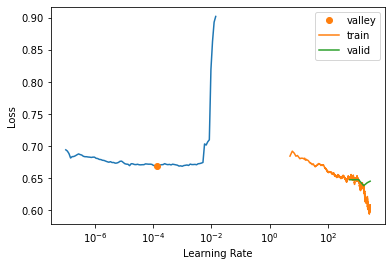

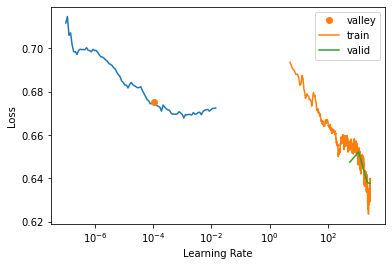

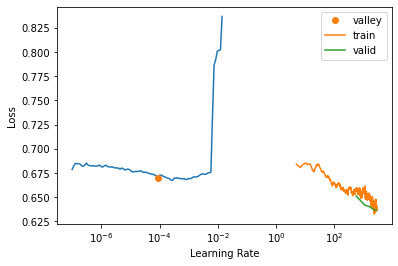

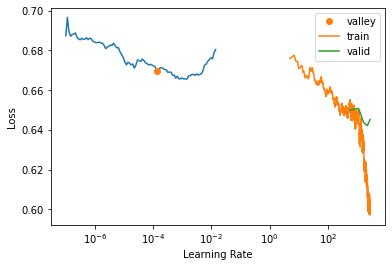

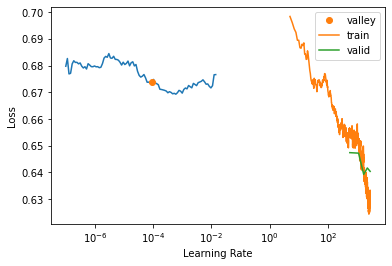

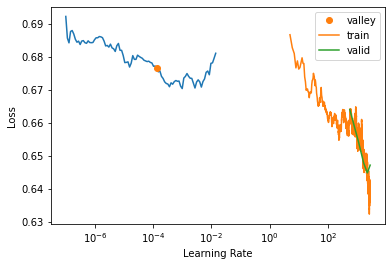

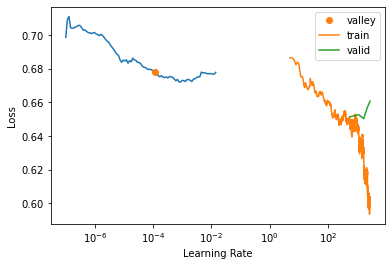

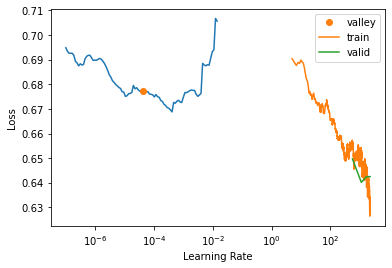

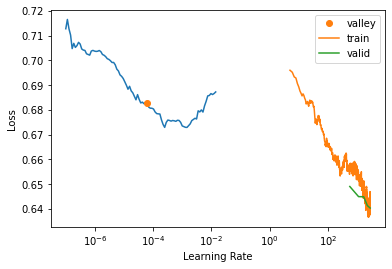

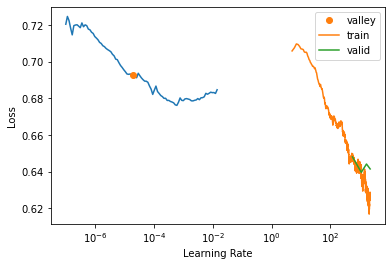

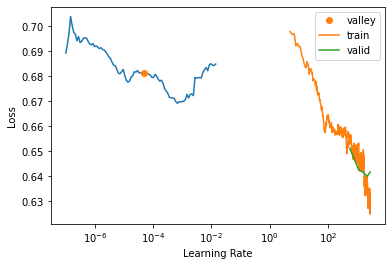

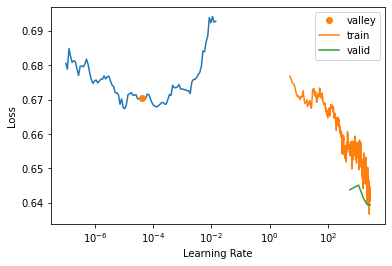

In [13]:
for i in range(args.num_splits):
    
    #Let us know where we are at
    print(f'Fold {i} results')
    
    #Get our model
    learn = get_learner(fold_num=i)
    
    #The original version of this notebook had the function outside the loop, by moving it inside the loop
    #We allow each learner to have it's own LR that works best for that specific fold
    lr = learn.lr_find(end_lr=3e-2)
    
    
    #We will fit 3-12 models, with 1/3 Standard, 1/3 with mixup, and 1/3 with cutmix
    if i % 3 == 0:
        print('No Mixing')
        #Learner is fit for a maximum of 5 epochs, but stops after 2 consecutive epochs with no improvement
        #To RMSE
        learn.fit_one_cycle(5, lr.valley, cbs=[SaveModelCallback(), 
                                           EarlyStoppingCallback(monitor='rmse', 
                                                                 comp=np.less, patience=2)])
    if i % 3 == 1:
        print('Mixup')
        mixup = MixUp()
        learn.fit_one_cycle(5, lr.valley, cbs=[mixup, SaveModelCallback(), 
                                       EarlyStoppingCallback(monitor='rmse', 
                                                             comp=np.less, patience=2)])
    if i % 3 == 2:
        print('CutMix')
        cutmix = CutMix()
        learn.fit_one_cycle(5, lr.valley, cbs=[cutmix, SaveModelCallback(), 
                                       EarlyStoppingCallback(monitor='rmse', 
                                                             comp=np.less, patience=2)])
    
    #Fastai does not allow us to export the model in fp 16, so we need to change it back to fp32
    learn.to_fp32()

    learn.export(f'{i}best_weights.pkl')

    learn.recorder.plot_loss()
    
    #Memory Management
    del learn, lr
    torch.cuda.empty_cache()
    gc.collect()

In [14]:
import requests


def lineNotifyMessage(token, msg):

    headers = {
        "Authorization": "Bearer " + token, 
        "Content-Type" : "application/x-www-form-urlencoded"
    }

    payload = {'message': msg }
    r = requests.post("https://notify-api.line.me/api/notify", headers = headers, params = payload)
    return r.status_code


token = 'SI7OfKEktqdB6fMJVZHTTyijxczxxsm7bufbFcflqMa'
msg = 'Training Completed'

lineNotifyMessage(token, msg)

200

After all of this training is complete, the result will be a set of 3-12 model weights. A separate notebook was used to make predictions. This notebook would import each of the 3-12 models, make the predictions and average them. The code for this notebook is below, just for reference.

The notebook had the same imports as this notebook (sys, timm, the timm dataset, and all the packages)

In [ ]:
#Creates a folder for our SWINL Model in the os path and copies the model from the timm data to this location
#This prevents the notebook from looking on the internet for the model
if not os.path.exists('/root/.cache/torch/hub/checkpoints/'):
    os.makedirs('/root/.cache/torch/hub/checkpoints/')
!cp '../input/swin-transformer/swin_large_patch4_window7_224_22kto1k.pth' '/root/.cache/torch/hub/checkpoints/swin_large_patch4_window7_224_22kto1k.pth'

In [ ]:
# Load our test data
tstdf = pd.read_csv(args.folder_name/'test.csv')
tstdf['filename'] = tstdf['Id'].map(lambda x:str(args.folder_name/'test'/x)+'.jpg')

In [ ]:
#Creating a column of fake Pawpularity scores to overwright later
tstdf['Pawpularity'] = [1]*len(tstdf)
tstdf = tstdf.drop(columns=['Id'])

In [ ]:
def get_learner(fold_num):
    data = get_data(fold_num)
    
    #Imports the learner based on the fold num
    learn = load_learner(f'../input/fastai-swinl/{fold_num}best_weights.pkl', cpu = False).to_fp16()
    
    return learn

In [ ]:
#We start by initializing the predictions list
all_preds = []

for i in range(args.num_splits):
    
    #First we pull in our model from the checkpoint
    learn = get_learner(fold_num=i)
    
    #We define our dataloader as the same as before
    dls = ImageDataLoaders.from_df(df,#pass in train DataFrame
                               valid_pct=.2, #80-20 train-validation random split
                               seed=args.seed, #seed
                               fn_col='filename', #filename is the column in the df that has the image paths
                               label_col='norm_score', #our scaled labels
                               y_block=RegressionBlock, #The type of target
                               bs= args.batch_size, #pass in batch size
                               num_workers= args.num_workers,
                               item_tfms= Resize(args.imagesize), #We will only be resizing items
                               batch_tfms=setup_aug_tfms( #All of these are to help with generalization
                                                        [Brightness(), Contrast(), Hue(), 
                                                          Saturation(), 
                                                          RandomErasing(p=.3, sh =.1, max_count = 2)])
                                  )
    
    #We assign our test set based on the data loader assigned above.
    test_dl = dls.test_dl(tstdf)
    
    #After lots of experimentation, the default test time augmentation parameters were best
    preds, _ = learn.tta(dl=test_dl)
    
    #add the predictions to our data frame
    all_preds.append(preds)
    
    #Memory Management
    del learn

    torch.cuda.empty_cache()

    gc.collect()

In [ ]:
#First we create the dataframe we will use to submit the sample
sample_df = pd.read_csv(args.folder_name/'sample_submission.csv')

#We take the simple mean of all the predictions.
preds = np.mean(np.stack(all_preds), axis=0)

#Scale them back up from the "norm score"
sample_df['Pawpularity'] = preds*100

#And save
sample_df.to_csv('submission.csv',index=False)

In [ ]:
#Just to check
pd.read_csv('submission.csv').head()

# **Reference**
###  [Petfinder Pawpularity EDA & fastai starter 🐱🐶](https://www.kaggle.com/tanlikesmath/petfinder-pawpularity-eda-fastai-starter)
###  [Petfinder& fastai with DataAugmentation KFold 10](https://www.kaggle.com/bobber/petfinder-fastai-with-dataaugmentation-kfold-10)
###  [Lovely Doggo with Bonky (fastai &timm)](https://www.kaggle.com/warotjanpinitrat/lovely-doggo-with-bonky-fastai-timm)